generating artificial data samples: 100%|██████████| 10/10 [00:00<00:00, 2602.09it/s]


(10, 4096)
haar dont work
db1 dont work
db2 dont work
db3 dont work
db4 dont work
db5 dont work
db6 dont work
db7 dont work
db8 dont work
db9 dont work
db10 dont work
db11 dont work
db12 dont work
db13 dont work
db14 dont work
db15 dont work
db16 dont work
db17 dont work
db18 dont work
db19 dont work
db20 dont work
db21 dont work
db22 dont work
db23 dont work
db24 dont work
db25 dont work
db26 dont work
db27 dont work
db28 dont work
db29 dont work
db30 dont work
db31 dont work
db32 dont work
db33 dont work
db34 dont work
db35 dont work
db36 dont work
db37 dont work
db38 dont work
sym2 dont work
sym3 dont work
sym4 dont work
sym5 dont work
sym6 dont work
sym7 dont work
sym8 dont work
sym9 dont work
sym10 dont work
sym11 dont work
sym12 dont work
sym13 dont work
sym14 dont work
sym15 dont work
sym16 dont work
sym17 dont work
sym18 dont work
sym19 dont work
sym20 dont work
coif1 dont work
coif2 dont work
coif3 dont work
coif4 dont work
coif5 dont work
coif6 dont work
coif7 dont work
coif8

/tmp/ipykernel_29957/2046125345.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family shan, without parameters specified in the name are deprecated. The name should takethe form shanB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: shan1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)
/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets of family fbsp, without parameters specified in the name are deprecated.  The name should take the form fbspM-B-C where M is the spline order and B, C are floats representing the bandwidth frequency and center frequency, respectively (example: fbsp1-1.5-1.0).
  wavelet = Discre

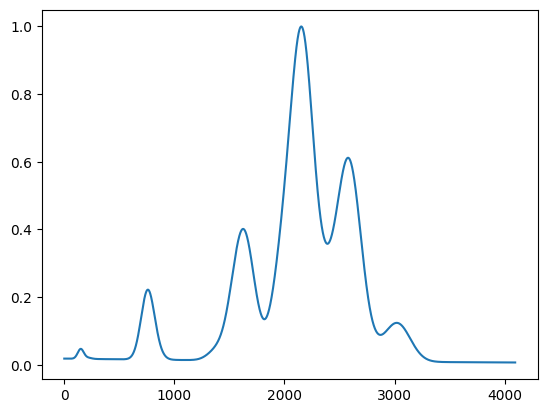

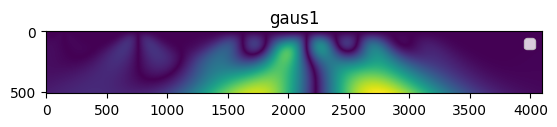

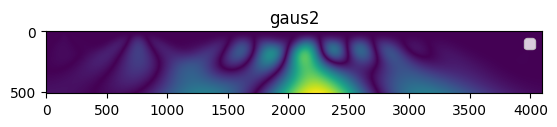

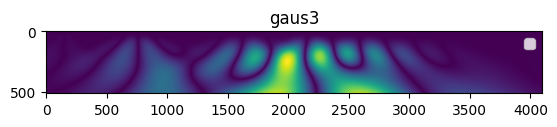

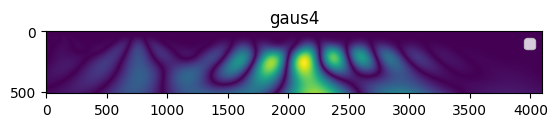

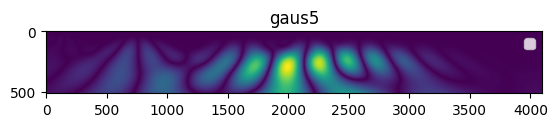

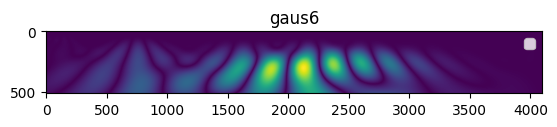

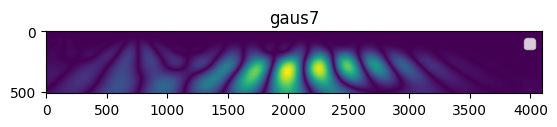

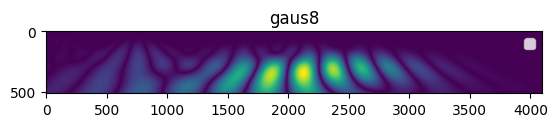

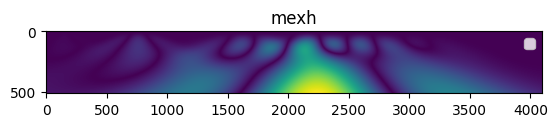

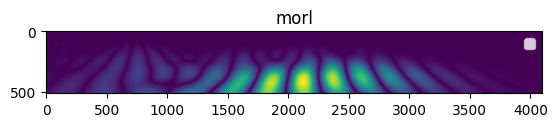

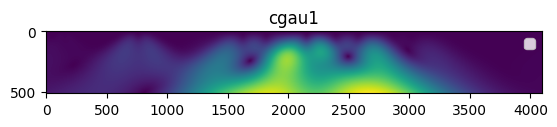

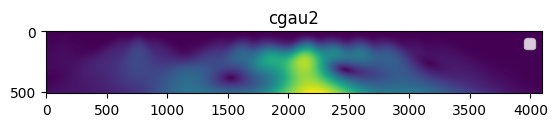

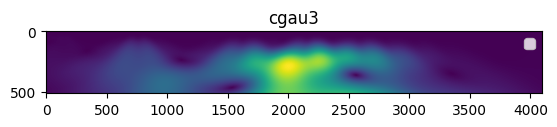

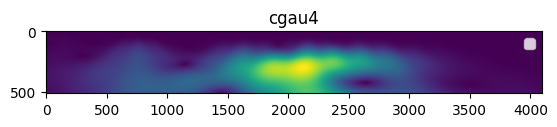

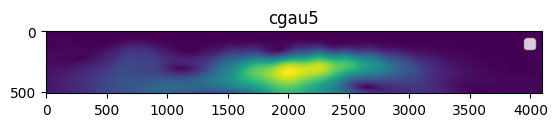

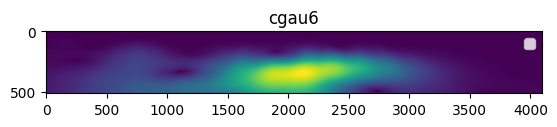

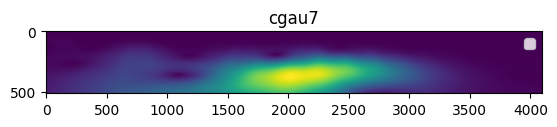

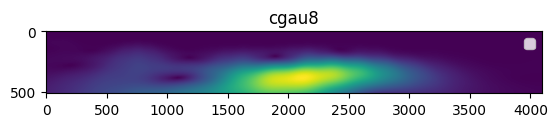

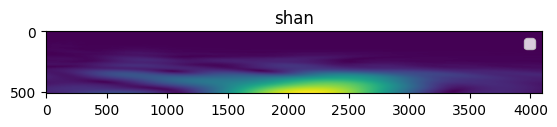

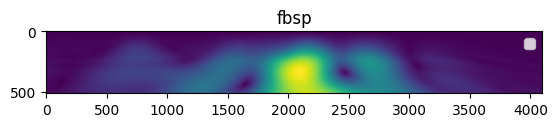

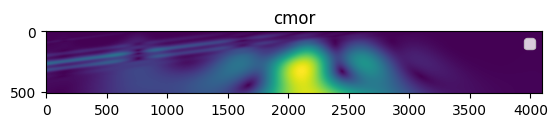

In [2]:
from sklearn.model_selection import train_test_split
from src.FeatureEnhancer import FeatureEnhancer 
from src.TrainDataGenerator import TrainDataGenerator
from src.Evaluation import Evaluation
from src.Elements import Elements 
from torchview import draw_graph
from tqdm import tqdm
import graphviz
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import pywt
import random 
from scipy.fft import fft

X, y = TrainDataGenerator.generate_artificial_data(samples=10, max_elements_per_sample=2, use_max=True, mu_max_err=0.0, mu_max_err_global=0.0, sigma_max_err=0.0, use_percentages=False, cache_element_samples=True)
# X = FeatureEnhancmentUtils.enhanced_features(X)
X_train, X_valid, y_train, y_valid= train_test_split(X, y, train_size=0.9, shuffle=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
train_loader = Evaluation.create_dataloader(X_train, y_train, DEVICE, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = Evaluation.create_dataloader(X_valid, y_valid, DEVICE, batch_size=BATCH_SIZE, shuffle=True)

plt.plot(X[0])
print(X.shape)

# res = fft(X[0])
# plt.plot(res/np.max(res))
for family in pywt.families():
    wavelets = pywt.wavelist(family)
    for wavelet in wavelets:
        try:
            coefs, freqs = pywt.cwt(X[0], list(range(1, 512)), wavelet)

            plt.figure(random.randint(1, int(10e10)))
            plt.title(wavelet)
            plt.imshow(abs(coefs))
            plt.legend()
        except:
            print(f"{wavelet} dont work")


# plt.figure(3)
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plt.plot(X[0, 0, 1], label="original")
# plt.plot(X[0, 1, 1], label="rdr")
# plt.plot(X[0, 0, 1] * X[0, 1, 4], label="original*rdr")

# plt.figure(2)
# fig, ax = plt.subplots(3, 1, figsize=(10, 6))

# im = ax[0].imshow(X[0, 0], label="original", aspect="auto", interpolation="None")
# ax[0].set_title('Original Features')

# ax[1].imshow(X[0, 1], label="rdr", aspect="auto", interpolation="None")
# ax[1].set_title('Reduced Dynamic Range Features')

# ax[2].imshow(X[0, 1] * X[0, 0], label="original*rdr", aspect="auto", interpolation="None")
# ax[2].set_title('rdr * original')

# plt.tight_layout()
# plt.colorbar(im, ax=ax)
# plt.savefig("spectra_heatmaps.svg")
# print(X.shape)


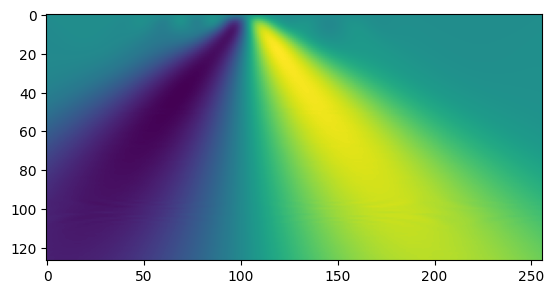

In [17]:
plt.imshow(coefs)

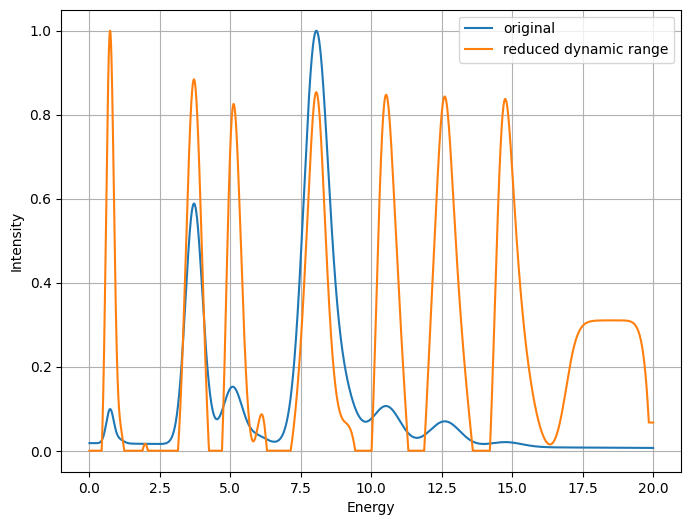

<Figure size 640x480 with 0 Axes>

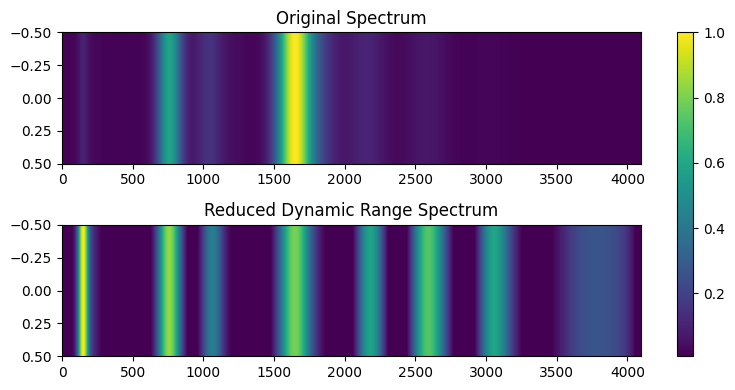

In [3]:

energy_range = np.linspace(TrainDataGenerator.MIN_ENERGY, TrainDataGenerator.MAX_ENERGY, TrainDataGenerator.CHANNELS_COUNT)
sample, target = TrainDataGenerator.generate_sample(energy_range
                                                    , selected_elements = ["ca", "cu", "pb"]
                                                    , element_percentages = [0.6, 1, 0.1]
                                                    , mu_err_global = 0
                                                    , mu_max_err = 0
                                                    , sigma_max_err = 0
                                                    , scale_sigma = 1
                                                    , set_percentages = False)

plt.figure(figsize=(8, 6))
plt.plot(energy_range, sample, label="original")
plt.plot(energy_range, FeatureEnhancmentUtils.reduced_dynamic_range(sample, 64), label="reduced dynamic range")
plt.grid(True)
plt.xlabel("Energy")
plt.ylabel("Intensity")
plt.legend()
plt.savefig("spectra_plot.svg")



plt.figure(2)
fig, ax = plt.subplots(2, 1, figsize=(8, 4))

im = ax[0].imshow(np.expand_dims(sample, axis=0), label="original", aspect="auto")
ax[0].set_title('Original Spectrum')

ax[1].imshow(np.expand_dims(FeatureEnhancmentUtils.reduced_dynamic_range(sample, 128), axis=0), label="original", aspect="auto")
ax[1].set_title('Reduced Dynamic Range Spectrum')

plt.tight_layout()
plt.colorbar(im, ax=ax)
plt.savefig("spectra_heatmaps.svg")


In [3]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
X, y = TrainDataGenerator.generate_artificial_data(samples=20000, max_elements_per_sample=5, mu_max_err=0.0, mu_max_err_global=0.0, sigma_max_err=0.0, use_percentages=False, cache_element_samples=True)


generating artificial data samples: 100%|██████████| 4000/4000 [00:03<00:00, 1173.93it/s]


In [ ]:
X = FeatureEnhancmentUtils.enhanced_features(X)

enhancing data features:  60%|██████    | 10059/16665 [09:19<06:13, 17.67it/s]

In [5]:
BATCH_SIZE = 16

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.9, shuffle=True)
train_loader = Evaluation.create_dataloader(X_train, y_train, DEVICE, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = Evaluation.create_dataloader(X_valid, y_valid, DEVICE, batch_size=BATCH_SIZE, shuffle=True)

for X_batch, y_batch in train_loader:
    plt.plot(X_batch[0, 0, 6].cpu().detach().numpy())
    plt.plot(X_batch[0, 1, 6].cpu().detach().numpy())
    print(X_batch.shape)
    print(y_batch.shape)
    break

IndexError: too many indices for tensor of dimension 2

1754887


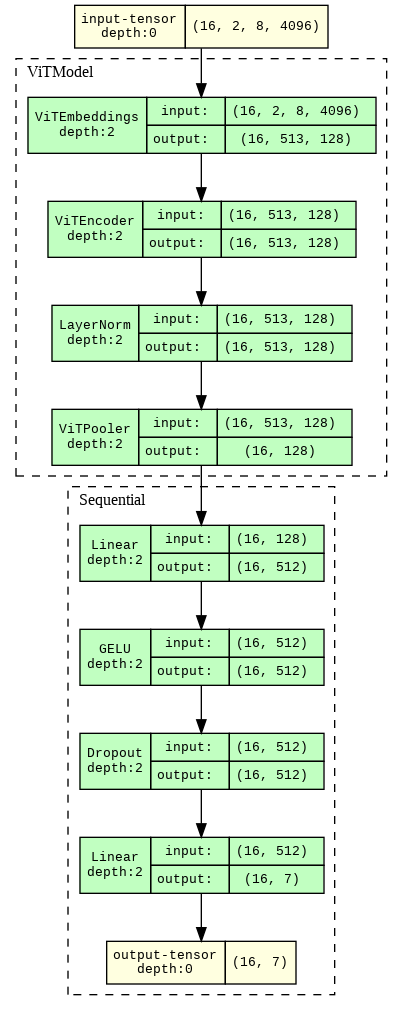

In [4]:
from transformers import ViTModel, ViTConfig

input_size = TrainDataGenerator.CHANNELS_COUNT
num_classes = len(Elements.ELEMENT_LINES.keys())
num_channels = 2
num_kernels = 8
embed_dim = num_channels * num_kernels**2
patch_size = num_kernels
num_heads = 8
num_layers = 8
hidden_dim = 4 * embed_dim
dropout_rate = 0.05

class ViTWithCustomHead(nn.Module):
    def __init__(self, vit_model, num_classes, dropout=0.5):
        super(ViTWithCustomHead, self).__init__()
        self.vit = vit_model  # The ViT backbone
        self.custom_head = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, self.vit.config.intermediate_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.vit.config.intermediate_size, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_output = outputs.pooler_output
        logits = self.custom_head(cls_output)
        return logits


vit_config = ViTConfig(hidden_size=embed_dim
                       , intermediate_size=hidden_dim
                       , num_channels=num_channels
                       , image_size=(num_kernels, input_size)
                       , patch_size=num_kernels
                       , encoder_stride=num_kernels
                       , num_attention_heads=num_heads
                       , num_hidden_layers=num_layers
                       , attention_probs_dropout_prob=dropout_rate
                       , hidden_dropout_prob=dropout_rate)
model = ViTWithCustomHead(ViTModel(vit_config), num_classes).to(DEVICE)


pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graph = draw_graph(model, input_size=(16, 2, 8, 4096), expand_nested=True, depth=2)
graphviz.set_jupyter_format('png')
graph.visual_graph

In [ ]:
import sys

class TrainDataGeneratorTorch():
    CHANNELS_COUNT = 4096
    TARGET_VECTOR_LENGTH = len(Elements.ELEMENT_LINES.keys())
    CACHED_ELEMENT_SAMPLES = {}
    MIN_ENERGY = 0
    MAX_ENERGY = 20

    @staticmethod
    def gaussian(x, mu, sigma):
        """Return Gaussian distribution values."""
        return torch.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / (sigma * torch.sqrt(torch.tensor(2 * np.pi)))

    @staticmethod
    def get_random_percentages(n):
        """Generate a list of random percentages that sum to 1."""
        percentages = torch.rand(n)
        return percentages / torch.sum(percentages)

    @staticmethod
    def sample_elements(elements_count, selected_elements=None):
        """Sample a given number of elements."""
        if selected_elements is None:
            return random.sample(list(Elements.ELEMENT_LINES.keys()), elements_count)
        return [el if el in Elements.ELEMENT_LINES.keys() else Elements.NUM2SYMBOL[el] for el in selected_elements]

    @staticmethod
    def add_escape_peak(energy_range, element_line, element_sample, mu_err_global, mu_max_err, sigma_max_err, scale_sigma):
        """Add escape peak to the element sample if conditions are met."""
        mu_esc = element_line["mu"] - Elements.ESCAPE_ENERGY_DIFF + torch.rand(1).item() * (2 * mu_max_err) - mu_max_err + mu_err_global
        sigma = Elements.calculate_sigma(mu_esc) * scale_sigma + torch.rand(1).item() * (2 * sigma_max_err) - sigma_max_err
        intensity = element_line["intensity"] * Elements.ESCAPE_ENERGY_INTENSITY_RATIO
        gaussian = TrainDataGeneratorTorch.gaussian(energy_range, mu_esc, sigma)
        gaussian = gaussian / torch.max(gaussian)
        gaussian = gaussian * intensity
        element_sample = element_sample + gaussian
        return element_sample

    @staticmethod
    def add_cu_peak(energy_range, element_line, element_sample, mu_err_global, mu_max_err, sigma_max_err, scale_sigma):
        """Add copper peak to the element sample if conditions are met."""
        mu_cu = Elements.CU_THRESHOLD_ENERGY + torch.rand(1).item() * (2 * mu_max_err) - mu_max_err + mu_err_global
        sigma = Elements.calculate_sigma(mu_cu) * scale_sigma + torch.rand(1).item() * (2 * sigma_max_err) - sigma_max_err
        intensity = element_line["intensity"] * Elements.ESCAPE_ENERGY_INTENSITY_RATIO
        gaussian = TrainDataGeneratorTorch.gaussian(energy_range, mu_cu, sigma)
        gaussian = gaussian / torch.max(gaussian)
        gaussian = gaussian * intensity
        element_sample = element_sample + gaussian
        return element_sample

    @staticmethod
    def _generate_element_sample(energy_range, element, mu_err_global, mu_max_err, sigma_max_err, scale_sigma, cache_element_samples, device):
        """Generate a sample for a single element."""
        if cache_element_samples and element in TrainDataGeneratorTorch.CACHED_ELEMENT_SAMPLES:
            return TrainDataGeneratorTorch.CACHED_ELEMENT_SAMPLES[element].clone().to(device)

        element_sample = torch.zeros(TrainDataGeneratorTorch.CHANNELS_COUNT)
        for element_line in Elements.get_parsed_element_lines(element):
            mu = element_line["mu"] + torch.rand(1).item() * (2 * mu_max_err) - mu_max_err + mu_err_global
            sigma = element_line["sigma"] * scale_sigma + torch.rand(1).item() * (2 * sigma_max_err) - sigma_max_err
            intensity = element_line["intensity"]
            gaussian = TrainDataGeneratorTorch.gaussian(energy_range, mu, sigma)
            gaussian = gaussian / torch.max(gaussian)
            gaussian = gaussian * intensity
            element_sample = element_sample + gaussian

            if mu > Elements.ESC_THRESHOLD_ENERGY:
                element_sample = TrainDataGeneratorTorch.add_escape_peak(energy_range, element_line, element_sample, mu_err_global, mu_max_err, sigma_max_err, scale_sigma)
            if mu > Elements.CU_THRESHOLD_ENERGY:
                element_sample = TrainDataGeneratorTorch.add_cu_peak(energy_range, element_line, element_sample, mu_err_global, mu_max_err, sigma_max_err, scale_sigma)

        element_sample = element_sample / torch.max(element_sample)

        if element not in TrainDataGeneratorTorch.CACHED_ELEMENT_SAMPLES:
            TrainDataGeneratorTorch.CACHED_ELEMENT_SAMPLES[element] = element_sample

        return element_sample.to(device)

    @staticmethod
    def generate_sample(energy_range, selected_elements, element_percentages, mu_err_global, mu_max_err, sigma_max_err, scale_sigma=1, set_percentages=False, cache_element_samples=False, device="cuda"):
        """Generate a single sample with specified elements and parameters."""
        sample = torch.zeros(TrainDataGeneratorTorch.CHANNELS_COUNT).to(device)
        target = torch.zeros(TrainDataGeneratorTorch.TARGET_VECTOR_LENGTH).to(device)

        for element_percentage, element in zip(element_percentages, selected_elements):
            target[Elements.SYMBOL2NUM[element]] = element_percentage if set_percentages else 1
            element_sample = TrainDataGeneratorTorch._generate_element_sample(energy_range, element, mu_err_global, mu_max_err, sigma_max_err, scale_sigma, cache_element_samples, device)
            element_sample = element_sample * element_percentage
            sample = sample + element_sample

        sample = sample / torch.max(sample)
        exponential = torch.exp(-torch.linspace(4, 5, TrainDataGeneratorTorch.CHANNELS_COUNT)).to(device)
        sample = sample + exponential
        sample = sample / torch.max(sample)
        return sample.to(device)

class PhysicsInformedLoss(nn.Module):
    def __init__(self, device="cpu", mse_weight=1.0, bce_weight=1.0):
        super(PhysicsInformedLoss, self).__init__()
        self.device = device
        self.mse_weight = mse_weight
        self.bce_weight = bce_weight
        self.mse_loss = nn.MSELoss()
        self.bce_loss = nn.BCELoss()
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, y_pred, y, X):
        X = X[:, :, 0, :].squeeze((1, 2))
        zero_tensor = torch.zeros_like(X).to(self.device)

        predicted_element_percentages = self.softmax(y_pred)
        artificial_spectra = torch.stack([TrainDataGeneratorTorch.generate_sample(energy_range=torch.linspace(TrainDataGenerator.MIN_ENERGY, TrainDataGenerator.MAX_ENERGY, TrainDataGenerator.CHANNELS_COUNT)
        , selected_elements=Elements.NUM2SYMBOL
                                                                                  , element_percentages=input, mu_err_global=0, mu_max_err=0, sigma_max_err=0, scale_sigma=1, set_percentages=False, cache_element_samples=True) for input in predicted_element_percentages], dim=0)
        spectra_diff = X - artificial_spectra

        bce_input = self.sigmoid(y_pred)

        # plt.plot(spectra_diff[0].cpu().detach().numpy(), label="diff")
        # plt.plot(X[0].cpu().detach().numpy(), label="X")
        # plt.plot(artificial_spectra[0].cpu().detach().numpy(), label="X_pred")
        # plt.legend()
        # sys.exit()
        mse = self.mse_loss(artificial_spectra, zero_tensor)
        bce = self.bce_loss(bce_input, y)
        return  self.bce_weight * bce + self.mse_weight * mse

In [ ]:
EPOCHS = 1
optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.BCEWithLogitsLoss()
# criterion = nn.BCELoss()
criterion = PhysicsInformedLoss(DEVICE)

torch.autograd.set_detect_anomaly(True)
train_history, valid_history, best_loss, best_weights = Evaluation.train(model, train_loader, valid_loader, optimizer, criterion, epochs = EPOCHS, physics_inormed_loss=True)

model.load_state_dict(best_weights)

Epoch 0
Batch 10, loss: 0.11492721736431122
Batch 20, loss: 0.06524090468883514
Batch 30, loss: 0.07687361538410187
Batch 40, loss: 0.06161978095769882
Batch 50, loss: 0.058567240834236145
Batch 60, loss: 0.06866970658302307
Batch 70, loss: 0.05764216557145119
Batch 80, loss: 0.058278705924749374
Batch 90, loss: 0.07621579617261887
Batch 100, loss: 0.05909150838851929
Batch 110, loss: 0.05607941001653671
Batch 120, loss: 0.07017157971858978
Batch 130, loss: 0.103038489818573
Batch 140, loss: 0.06766350567340851
train epoch avg loss: 0.08
valid loss: 0.06


<All keys matched successfully>

In [5]:
model.load_state_dict(torch.load('new_model.pt', map_location=DEVICE))
MODEL_NAME = "new_model"
torch.save(model.state_dict(), f"./{MODEL_NAME}.pt")

# print("loss: %.2f" % best_loss)

# plt.grid(True)
# plt.xlabel("epoch")
# plt.ylabel("loss")
# plt.xticks(range(len(train_history)))
# plt.title(f"{MODEL_NAME} loss")
# plt.plot(train_history, label="train avg loss")
# plt.plot(valid_history, label="valid loss")
# plt.legend()
# plt.savefig(f"{MODEL_NAME}_loss.svg")

enhancing data features: 100%|██████████| 1000/1000 [00:53<00:00, 18.83it/s]


Avg auc: 0.9795365820180232


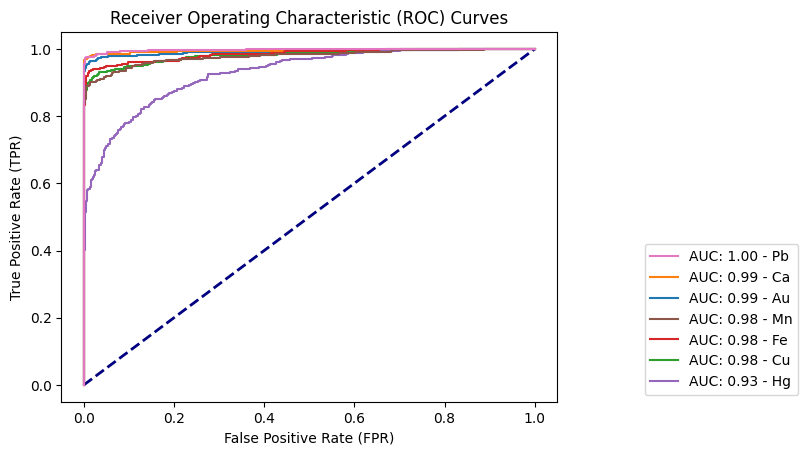

In [ ]:
Evaluation.calculate_roc(Evaluation.create_test_dataloader(5, samples=1000, device=DEVICE, use_max=False))


enhancing data features: 100%|██████████| 14/14 [00:00<00:00, 27.09it/s]


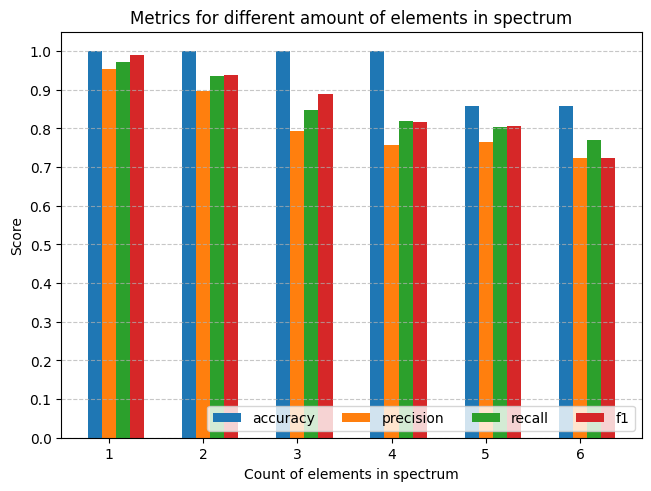

In [ ]:
test_loaders = [Evaluation.create_test_dataloader(i, device=DEVICE, samples=100 // num_classes, use_max=True) for i in range(1, num_classes)]
accuracy_precision_recall_f1s = [Evaluation.calculate_accuracy_precision_recall_f1(model, test_loader) for test_loader in test_loaders]

accuracy, precisions, recals, f1s = list(zip(*accuracy_precision_recall_f1s))

element_counts  = list(range(1, len(Elements.Lines.keys())))
fig, ax = plt.subplots(constrained_layout='constrained')
ax.grid(axis='y', linestyle='--', alpha=0.7)

stats_dict = {"accuracy": accuracy, "precision": precisions, "recall": recals, "f1": f1s}

width = 0.15  # the width of the bars
multiplier = 0
x = np.arange(len(element_counts))
for attribute, measurement in stats_dict.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

ax.set_ylabel('Score')
ax.set_xlabel('Count of elements in spectrum')
ax.set_title('Metrics for different amount of elements in spectrum')
ax.set_xticks(x + width, element_counts)
ax.set_yticks(np.linspace(0, 1, 11))
ax.legend(loc='lower right', ncols=4)
plt.savefig("vit_equal_classes_scores.svg")


In [7]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class DataPreprocessing():
    @staticmethod
    def get_processed_spectrum(spectrum, peaks, energies, min_energy=0, max_energy=20, energy_margin=1, target_length=TrainDataGenerator.CHANNELS_COUNT):
        # Calculate channel to energy mapping
        correction_coefficients = np.polyfit(peaks, energies, 1)
        energy_range = np.poly1d(correction_coefficients)(np.arange(spectrum.shape[-1]))

        # Fit spectrum within the energy range [min_energy, max_energy]
        mask = (energy_range >= min_energy) & (energy_range <= max_energy)
        energy_range_mapped = energy_range[mask]
        spectrum_acc_mapped = spectrum[mask]

        # Mask edges of spectrum by energy_margin to reduce noise
        energy_margin_idx = int((energy_margin / (max_energy - min_energy)) * (spectrum_acc_mapped.shape[-1]))
        spectrum_acc_mapped[: int(energy_margin_idx)] = spectrum_acc_mapped[energy_margin_idx]
        spectrum_acc_mapped[-int(energy_margin_idx): ] = spectrum_acc_mapped[-energy_margin_idx]

        # Interpolate to achieve target_length
        interpolation_energy_range = np.linspace(energy_range_mapped[0], energy_range_mapped[-1], target_length)
        spectrum_acc_interpolated = interp1d(energy_range_mapped, spectrum_acc_mapped, kind='linear', fill_value="extrapolate")(interpolation_energy_range)

        # Normalize spectrum
        spectrum_acc_interpolated = spectrum_acc_interpolated / (np.max(spectrum_acc_interpolated) + 10e-10)

        # plt.plot(interpolation_energies, gaussian_filter1d(spectrum_acc_interpolated, 128))

        return interpolation_energy_range, spectrum_acc_interpolated

    @staticmethod
    def process(e_xy, peaks, energies, min_energy=0, max_energy=20, energy_margin=1, target_length=TrainDataGenerator.CHANNELS_COUNT, enhance=True):
        result = np.zeros((*e_xy.shape[:-1], target_length))
        energy_range = None
        for i in tqdm(range(e_xy.shape[0]), desc="processing data row"):
            for j in range(e_xy.shape[1]):
                energy_range, result[i, j] = DataPreprocessing.get_processed_spectrum(e_xy[i, j], peaks, energies, min_energy, max_energy, energy_margin, target_length)

        if enhance:
            previous_shape = result.shape
            result = FeatureEnhancmentUtils.enhanced_features(result.reshape(-1, target_length))
            new_shape = result.shape
            result = result.reshape((*previous_shape[:-1], *new_shape[1:]))

        return energy_range, result


peaks_copper_plate = [720, 985, 1594, 2068]
energies_copper_plate = [3.692, 5.088, 8.046, 10.551]

channel_energies, spectrum= DataPreprocessing.get_processed_spectrum(e_xy[25, 25], peaks_copper_plate, energies_copper_plate)
spectrum_acc = spectrum / np.max(spectrum)

np.save("copper_pcb_preprocessed_spectrum.npy", spectrum)


In [8]:
chunk_size = 4
e_xy_averaged = e_xy.reshape(e_xy.shape[0] // chunk_size, chunk_size,
                             e_xy.shape[1] // chunk_size, chunk_size,
                             e_xy.shape[-1]).mean(axis=(1, 3))

In [9]:
energy_range, e_xy_preprocessed = DataPreprocessing.process(e_xy_averaged, peaks_copper_plate, energies_copper_plate, enhance=True)

enhancing data features: 100%|██████████| 1024/1024 [00:27<00:00, 37.75it/s]


In [ ]:
preds = np.zeros((*e_xy_preprocessed.shape[:2], num_classes))

with torch.no_grad():
    for i in tqdm(range(e_xy_preprocessed.shape[0]), desc="processing data row"):
        preds[i] = model.forward(torch.tensor(e_xy_preprocessed[i])).detach().cpu().numpy()


processing data row:   0%|          | 0/32 [00:00<?, ?it/s]